#Laboratory work 5. Deep Learning Clustering

#Part 1: Deep Learning Clustering (Unsupervised)

In [15]:
#imports

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

###Step 1. Loading dataset. MNIST

In [16]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False) #ignoring labels

###Step 2. Building autoencoder

In [17]:
#Input: 784 → Latent: 16 → Reconstruct back

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)  # latent space (z)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

###Step 3. Training model

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
losses = []

In [19]:
for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.view(images.size(0), -1).to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.0514
Epoch [2/10], Loss: 0.0269
Epoch [3/10], Loss: 0.0214
Epoch [4/10], Loss: 0.0181
Epoch [5/10], Loss: 0.0163
Epoch [6/10], Loss: 0.0152
Epoch [7/10], Loss: 0.0143
Epoch [8/10], Loss: 0.0136
Epoch [9/10], Loss: 0.0130
Epoch [10/10], Loss: 0.0125


###Step 4. Plotting training loss

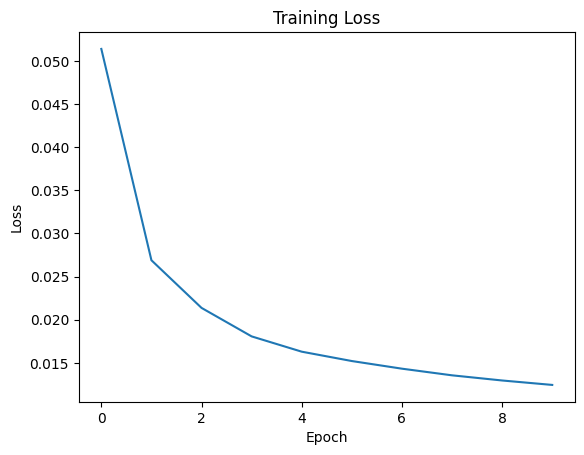

In [20]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

###Step 5. Extracting latent vectors

In [21]:
model.eval()

latent_vectors = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        z = model.encoder(images)

        latent_vectors.append(z.cpu().numpy())
        true_labels.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors)
true_labels = np.concatenate(true_labels)

print(latent_vectors.shape)  # should be (10000, 16)

(10000, 16)


###Step 6. Applying K-Means clustering

In [22]:
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(latent_vectors)

###Step 7. PCA visualization

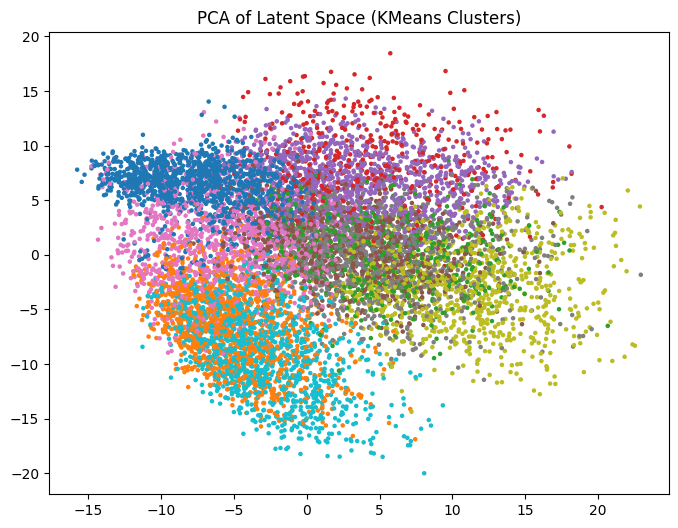

In [23]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='tab10', s=5)
plt.title("PCA of Latent Space (KMeans Clusters)")
plt.show()

###Step 8. Confusion Matrix

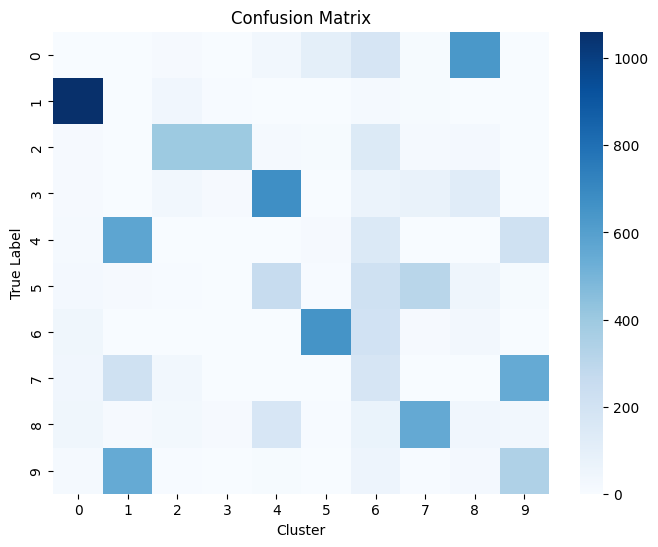

In [24]:
cm = confusion_matrix(true_labels, clusters)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

###t-SNE version

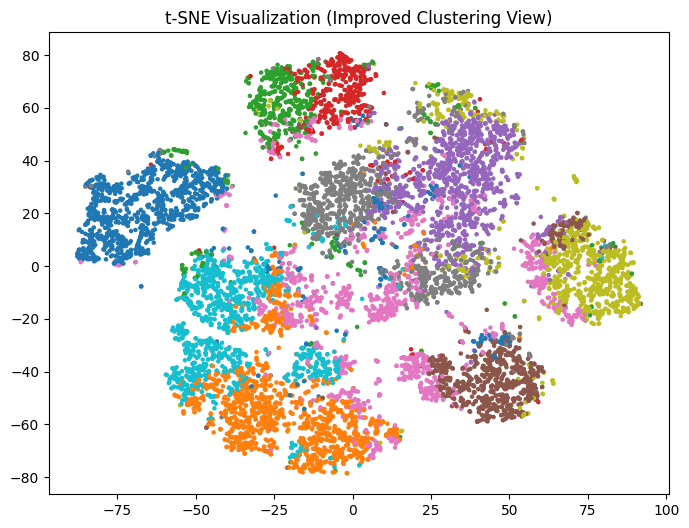

In [25]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(8,6))
plt.scatter(latent_tsne[:,0], latent_tsne[:,1], c=clusters, cmap='tab10', s=5)
plt.title("t-SNE Visualization (Improved Clustering View)")
plt.show()

The PCA visualization shows overlapping clusters because it is a linear projection. To better capture the non-linear structure of the latent space, t-SNE was applied. The resulting visualization shows clearer grouping of similar digits, demonstrating that the learned representations contain meaningful structure even if clusters are not perfectly separable.

###Comparing PCA and t-SNE

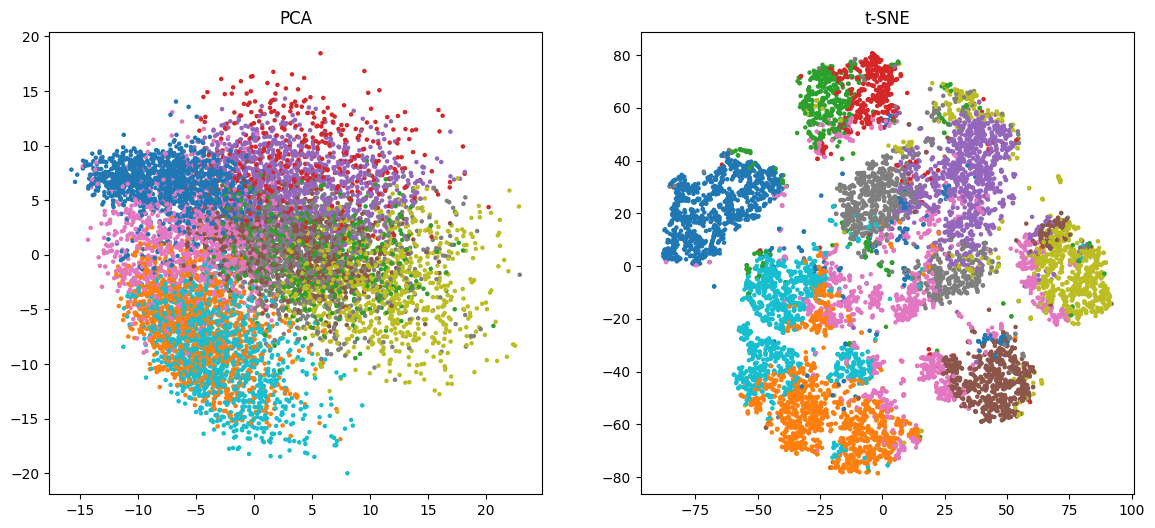

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# PCA
axes[0].scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='tab10', s=5)
axes[0].set_title("PCA")

# t-SNE
axes[1].scatter(latent_tsne[:,0], latent_tsne[:,1], c=clusters, cmap='tab10', s=5)
axes[1].set_title("t-SNE")

plt.show()

In [35]:
clustering_accuracy = np.mean(cluster_labels == true_labels)
print("Clustering Accuracy:", clustering_accuracy)

Clustering Accuracy: 0.637


#Part 2: Supervised CNN (Image Classification)

###Step 1. Dataset loading with labels

In [27]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

###Step 2. Defining CNN

In [28]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 → 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 14 → 7
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

###Step 3. Set up training

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
train_losses = []

###Step 4. Training CNN

In [30]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.1770
Epoch [2/5], Loss: 0.0487
Epoch [3/5], Loss: 0.0341
Epoch [4/5], Loss: 0.0258
Epoch [5/5], Loss: 0.0190


###Step 5. Plotting loss

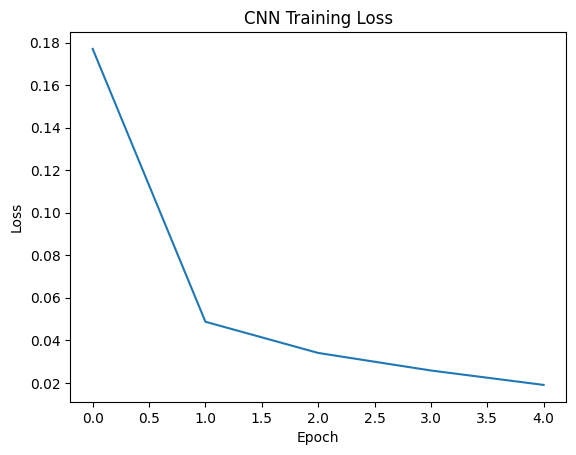

In [31]:
plt.plot(train_losses)
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

###Step 6. Evaluating model

In [32]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

###Step 7. Accuracy

In [33]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print("Accuracy:", accuracy)

Accuracy: 0.9902


###Step 8. Confusion matrix

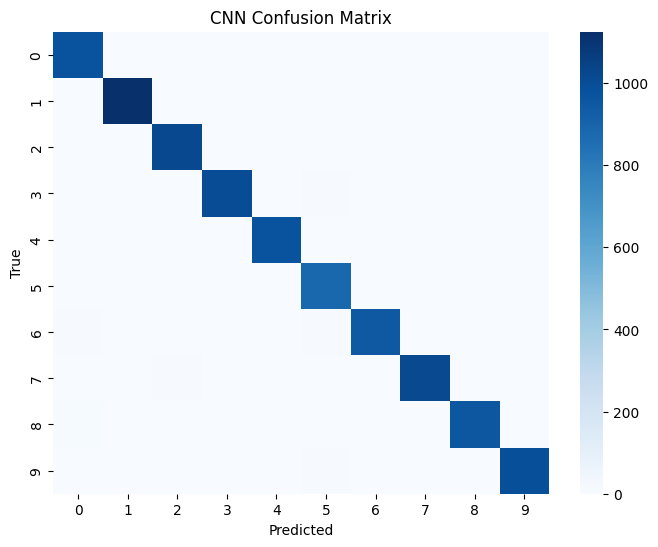

In [34]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#Comparative Analysis

In this lab I compare unsupervised clustering with supervised CNN, and the difference in results is very clear. The main reason why CNN performs better is because it uses labels during training, while clustering does not. In the autoencoder model, we only try to reconstruct the input images, so the model learns general features like shape or strokes, but not the actual meaning of digits. Because of this, in latent space digits that look similar (for example 3 and 5 or 4 and 9) are often grouped together, even if they are different classes.

Also K-Means algorithm assumes that clusters are simple and separated, but MNIST data is more complex and not perfectly separable. That is why confusion matrix for clustering looks messy and many classes overlap.

On the other hand CNN is trained directly with correct labels, so it learns discriminative features that help to separate digits much better. This can be clearly seen from almost perfect confusion matrix and high accuracy (around 99%)

So overall, supervised learning works better for classification tasks, while unsupervised methods are more useful for exploring structure of data, but not for precise labeling